cell 1

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


cell 2


In [2]:
!pip install praat-parselmouth librosa xgboost shap -q
print("✅ 套件安裝完成")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 91.8 MB/s eta 0:00:00
✅ 套件安裝完成


cell 3


In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import parselmouth
from parselmouth.praat import call
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ===== 路徑設定 =====
BASE_DIR   = '/content/drive/MyDrive/voice_age_project_0428/voice_age_project_0428'
AUDIO_DIR  = os.path.join(BASE_DIR, 'AudioWAV')
DEMO_CSV   = os.path.join(BASE_DIR, 'VideoDemographics.csv')
OUTPUT_CSV = os.path.join(BASE_DIR, 'features.csv')  # 特徵表存回 Drive

print(f"音檔資料夾：{AUDIO_DIR}")
print(f"人口資料檔：{DEMO_CSV}")
print(f"音檔數量：{len(os.listdir(AUDIO_DIR))}")

音檔資料夾：/content/drive/MyDrive/voice_age_project_0428/voice_age_project_0428/AudioWAV
人口資料檔：/content/drive/MyDrive/voice_age_project_0428/voice_age_project_0428/VideoDemographics.csv
音檔數量：7442


cell 4

In [4]:
demo_df = pd.read_csv(DEMO_CSV)
print("欄位：", demo_df.columns.tolist())
print(demo_df.head(10))
print(f"\n演員人數：{len(demo_df)}")
print(f"年齡範圍：{demo_df['Age'].min()} – {demo_df['Age'].max()} 歲")
print(f"\n年齡分佈：")
print(demo_df['Age'].describe())

欄位： ['ActorID', 'Age', 'Sex', 'Race', 'Ethnicity']
   ActorID  Age     Sex              Race     Ethnicity
0     1001   51    Male         Caucasian  Not Hispanic
1     1002   21  Female         Caucasian  Not Hispanic
2     1003   21  Female         Caucasian  Not Hispanic
3     1004   42  Female         Caucasian  Not Hispanic
4     1005   29    Male  African American  Not Hispanic
5     1006   58  Female         Caucasian  Not Hispanic
6     1007   38  Female  African American  Not Hispanic
7     1008   46  Female         Caucasian  Not Hispanic
8     1009   24  Female         Caucasian  Not Hispanic
9     1010   27  Female         Caucasian  Not Hispanic

演員人數：91
年齡範圍：20 – 74 歲

年齡分佈：
count    91.000000
mean     36.428571
std      13.269968
min      20.000000
25%      25.000000
50%      33.000000
75%      45.500000
max      74.000000
Name: Age, dtype: float64


cell 5

In [5]:
def extract_features(wav_path):
    """
    輸入：一個 .wav 檔案路徑
    輸出：包含 F0, Jitter, Shimmer, HNR, 13維MFCC 的 dict
          若讀取失敗回傳 None
    """
    try:
        # === 用 parselmouth 提取生理聲學指標 ===
        sound = parselmouth.Sound(wav_path)

        # 基頻 F0（每秒振動次數，Hz）
        pitch = call(sound, "To Pitch", 0.0, 75, 600)
        f0_mean = call(pitch, "Get mean", 0, 0, "Hertz")

        # Jitter（頻率微擾，%）
        point_process = call(sound, "To PointProcess (periodic, cc)", 75, 600)
        jitter = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)

        # Shimmer（振幅微擾，%）
        shimmer = call(
            [sound, point_process],
            "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6
        )

        # HNR（諧波雜訊比，dB）
        harmonicity = call(sound, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr = call(harmonicity, "Get mean", 0, 0)

        # === 用 librosa 提取 13 維 MFCC ===
        y, sr = librosa.load(wav_path, sr=16000)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_means = np.mean(mfccs, axis=1)  # 每維取時間平均，得到 13 個數字

        # === 整合成一個 dict ===
        features = {
            'F0_mean':  f0_mean  if not np.isnan(f0_mean)  else 0.0,
            'Jitter':   jitter   if not np.isnan(jitter)   else 0.0,
            'Shimmer':  shimmer  if not np.isnan(shimmer)  else 0.0,
            'HNR':      hnr      if not np.isnan(hnr)      else 0.0,
        }
        for i, val in enumerate(mfcc_means):
            features[f'MFCC_{i+1}'] = val

        return features

    except Exception as e:
        return None

cell 6

In [10]:
# 從檔名解析 ActorID
# CREMA-D 檔名格式：1001_DFA_ANG_XX.wav → ActorID = 1001

records = []
wav_files = [f for f in os.listdir(AUDIO_DIR) if f.endswith('.wav')]
total = len(wav_files)

print(f"開始提取 {total} 個音檔的特徵...")

for idx, fname in enumerate(wav_files):
    if idx % 500 == 0:
        print(f"  進度：{idx}/{total}")

    actor_id = int(fname.split('_')[0])  # 取檔名第一段
    wav_path = os.path.join(AUDIO_DIR, fname)

    feats = extract_features(wav_path)
    if feats is not None:
        feats['ActorID'] = actor_id
        feats['filename'] = fname
        records.append(feats)

feature_df = pd.DataFrame(records)
print(f"\n✅ 成功提取 {len(feature_df)} 筆特徵")
print(feature_df.head())

開始提取 7442 個音檔的特徵...
  進度：0/7442


KeyboardInterrupt: 

cell 7

In [11]:
feature_df.to_csv(OUTPUT_CSV, index=False)
print(f"✅ 特徵表已儲存到 Drive：{OUTPUT_CSV}")

NameError: name 'feature_df' is not defined

cell 8

In [23]:
# 如果特徵已經提取過，直接讀這個 cell 就好
feature_df = pd.read_csv(OUTPUT_CSV)
print(f"✅ 讀取特徵表：{len(feature_df)} 筆")

✅ 讀取特徵表：7442 筆


cell 9

In [24]:
# 確認 demo_df 的 ActorID 欄位名稱
print("demo_df 欄位：", demo_df.columns.tolist())

# 合併（依 ActorID 對齊）
# 注意：如果欄位名稱不是 'ActorID' 要改成對應名稱
merged_df = feature_df.merge(
    demo_df[['ActorID', 'Age']],
    on='ActorID',
    how='inner'
)

print(f"合併後筆數：{len(merged_df)}")
print(f"年齡分佈：\n{merged_df['Age'].value_counts().sort_index()}")

demo_df 欄位： ['ActorID', 'Age', 'Sex', 'Race', 'Ethnicity']
合併後筆數：7442
年齡分佈：
Age
20    164
21    573
22    492
23    164
24    322
25    573
27    164
28     82
29    240
30    246
31    246
32    164
33    492
34    164
35     82
36    164
37     82
38    246
40    164
41     82
42    410
44     82
45    164
46    158
48    164
49     82
50     82
51    246
52     82
53     82
56    164
57    164
58     82
59     82
61    164
62    164
66     82
74     82
Name: count, dtype: int64


cell 10

Age Group Distribution:
AgeGroup
Young (20-35)     4168
Middle (36-50)    1880
Senior (51+)      1394
Name: count, dtype: int64


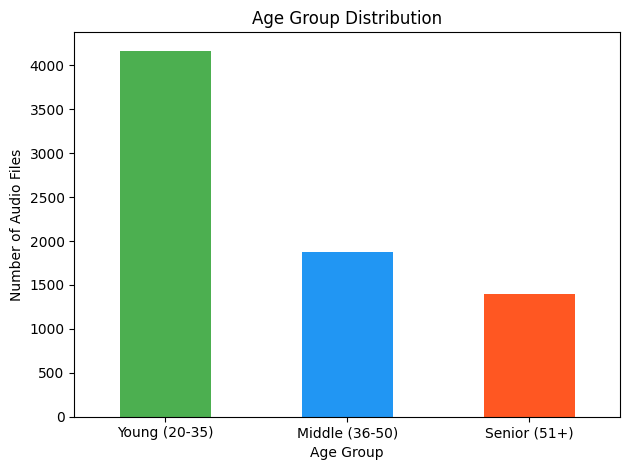

In [25]:
def age_to_label(age):
    if age <= 35:
        return 'Young (20-35)'
    elif age <= 50:
        return 'Middle (36-50)'
    else:
        return 'Senior (51+)'

merged_df['AgeGroup'] = merged_df['Age'].apply(age_to_label)

print("Age Group Distribution:")
print(merged_df['AgeGroup'].value_counts())

# 視覺化
colors = ['#4CAF50', '#2196F3', '#FF5722']
merged_df['AgeGroup'].value_counts().plot(kind='bar', color=colors)
plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Audio Files')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

先在這邊停


cell 11

In [26]:
# 選出特徵欄位
feature_cols = ['F0_mean', 'Jitter', 'Shimmer', 'HNR'] + \
               [f'MFCC_{i}' for i in range(1, 14)]

X = merged_df[feature_cols].values
y_raw = merged_df['AgeGroup'].values

# 標籤編碼（字串 → 數字）
le = LabelEncoder()
y = le.fit_transform(y_raw)
print("標籤對應：", dict(zip(le.classes_, le.transform(le.classes_))))

# 特徵標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 切分訓練集和測試集（8:2）
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"訓練集：{X_train.shape[0]} 筆")
print(f"測試集：{X_test.shape[0]} 筆")

標籤對應： {'Middle (36-50)': np.int64(0), 'Senior (51+)': np.int64(1), 'Young (20-35)': np.int64(2)}
訓練集：5953 筆
測試集：1489 筆


cell 12

In [27]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',   # 處理類別不平衡
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest 結果 ===")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

=== Random Forest 結果 ===
                precision    recall  f1-score   support

Middle (36-50)       0.46      0.44      0.45       376
  Senior (51+)       0.47      0.46      0.46       279
 Young (20-35)       0.71      0.73      0.72       834

      accuracy                           0.61      1489
     macro avg       0.55      0.54      0.54      1489
  weighted avg       0.60      0.61      0.60      1489



cell 13

In [28]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBoost 結果 ===")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

=== XGBoost 結果 ===
                precision    recall  f1-score   support

Middle (36-50)       0.55      0.36      0.44       376
  Senior (51+)       0.66      0.38      0.49       279
 Young (20-35)       0.68      0.88      0.77       834

      accuracy                           0.66      1489
     macro avg       0.63      0.54      0.56      1489
  weighted avg       0.64      0.66      0.63      1489



cell 14

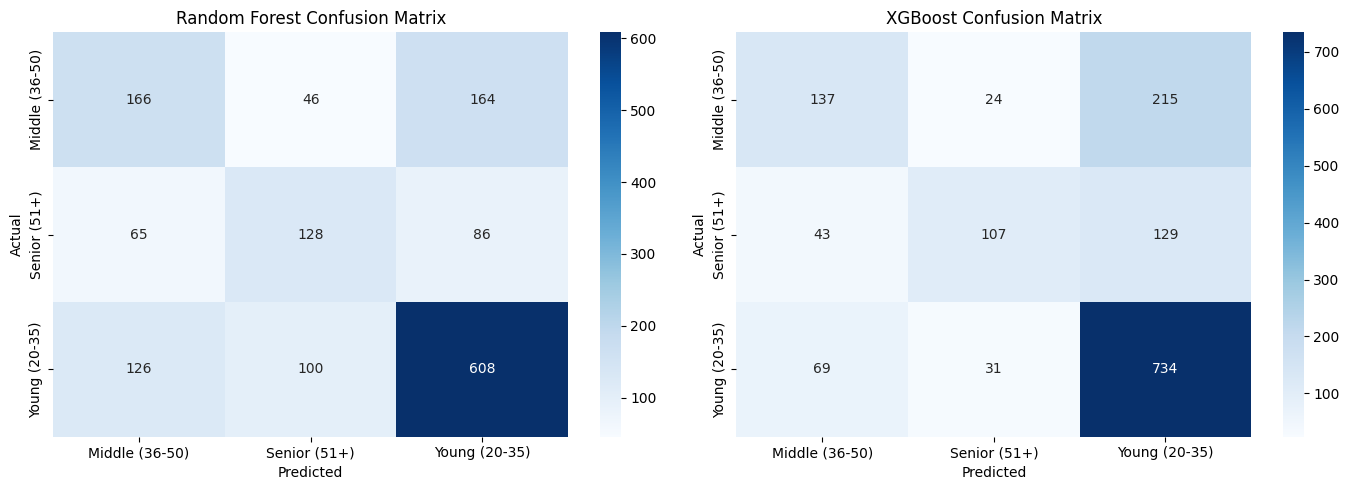

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(axes, [
    ('Random Forest', y_pred_rf),
    ('XGBoost',       y_pred_xgb)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_, ax=ax)
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

In [30]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
# SHAP with XGBoost

cell 15

In [31]:
print(f"shap_values type: {type(shap_values)}")

if isinstance(shap_values, list):
    print(f"shap_values is a LIST of {len(shap_values)} arrays")
    for i, sv in enumerate(shap_values):
        print(f"  index {i}: shape = {sv.shape}")
else:
    print(f"shap_values is an ARRAY: shape = {shap_values.shape}")

print(f"\nX_test shape: {X_test.shape}")
print(f"le.classes_: {le.classes_}")

shap_values type: <class 'numpy.ndarray'>
shap_values is an ARRAY: shape = (1489, 17, 3)

X_test shape: (1489, 17)
le.classes_: ['Middle (36-50)' 'Senior (51+)' 'Young (20-35)']


cell 16

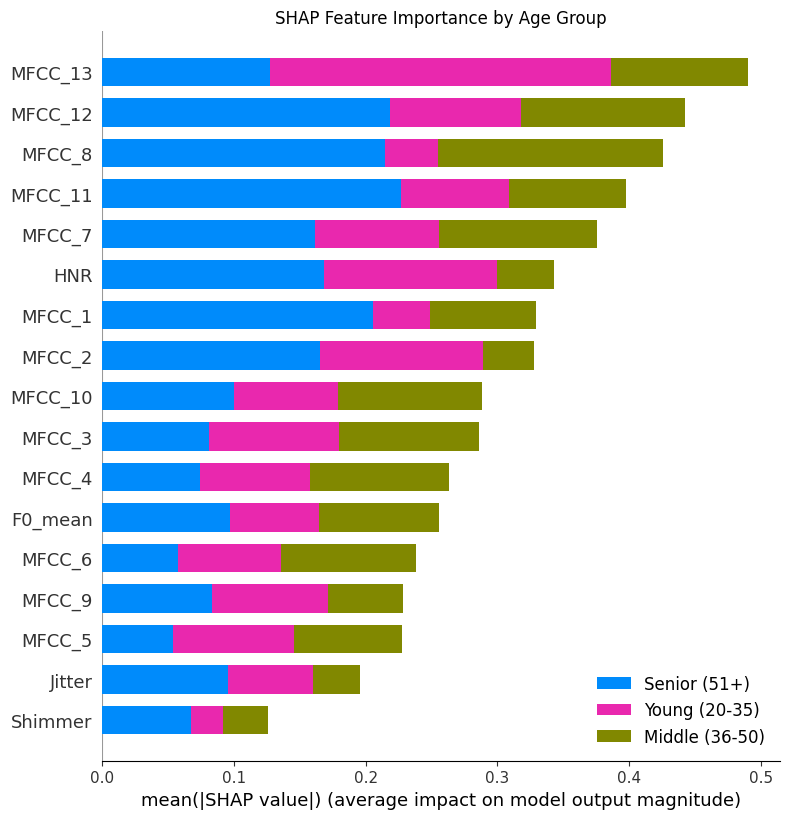

In [32]:
senior_idx = list(le.classes_).index('Senior (51+)')

plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_cols,
    class_names=le.classes_,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance by Age Group')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'shap_summary.png'), dpi=150)
plt.show()

cell 17

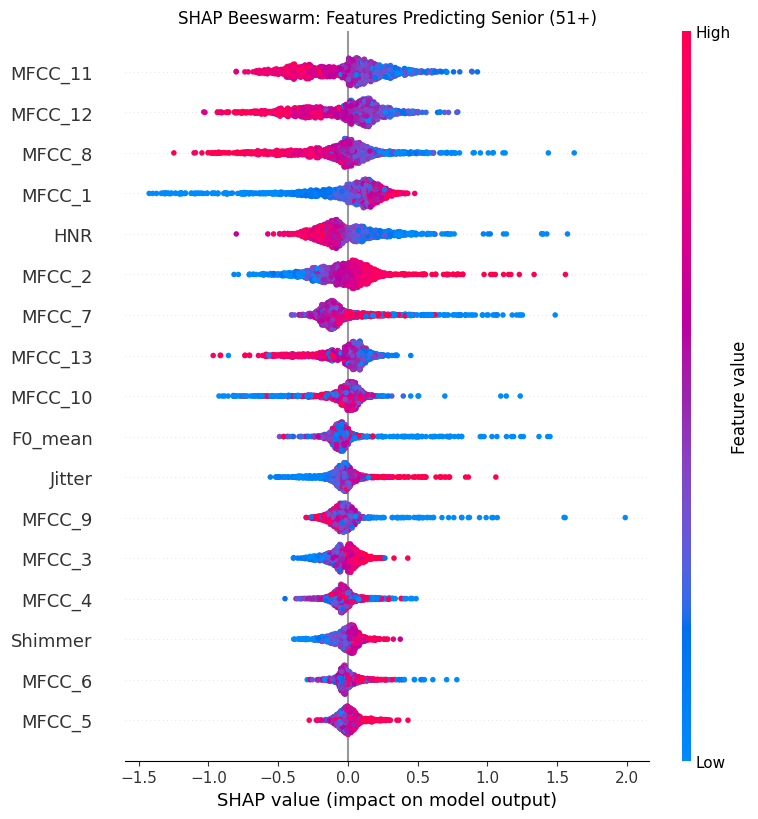

In [33]:
shap_senior = shap_values[:, :, senior_idx]  # shape: (1489, 17)

plt.figure()
shap.summary_plot(
    shap_senior,
    X_test,
    feature_names=feature_cols,
    show=False
)
plt.title('SHAP Beeswarm: Features Predicting Senior (51+)')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'shap_beeswarm.png'), dpi=150)
plt.show()

cell 18

In [34]:
import pickle
import os

# 存模型、scaler、label encoder
artifacts = {
    'xgb_model': xgb_model,
    'rf_model': rf_model,
    'scaler': scaler,
    'label_encoder': le,
    'feature_cols': feature_cols
}

artifact_path = os.path.join(BASE_DIR, 'model_artifacts.pkl')
with open(artifact_path, 'wb') as f:
    pickle.dump(artifacts, f)

print(f"✅ 模型已儲存：{artifact_path}")

✅ 模型已儲存：/content/drive/MyDrive/voice_age_project_0428/voice_age_project_0428/model_artifacts.pkl
